# Trend Following and FARIMA-GARCH

## 1. Imports

In [ ]:
%pip install rpy2

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install ruptures
%pip install openpyxl --user
%pip install scipy matplotlib numpy
%pip install pygam
%pip install --upgrade scikit-learn
%pip install "scipy>=1.10.0"
%pip install seaborn
%pip install pmdarima



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt
import datetime
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from ruptures.base import BaseCost
from scipy.interpolate import UnivariateSpline, LSQUnivariateSpline, make_lsq_spline, BSpline, splrep, splev, make_interp_spline
from numpy.polynomial.polynomial import Polynomial
from scipy.special import gamma
from pandas.tseries.offsets import BDay


from pygam import GAM, s
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.stattools import adfuller, kpss, acf, q_stat
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import seaborn as sns
import scipy.stats as stats
from arch import arch_model
from arch.univariate import GeneralizedError, Normal, StudentsT, SkewStudent
from scipy.stats import gaussian_kde
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
import pmdarima as pm
from arch.unitroot import ADF

import warnings
import statsmodels.api as sm

from rpy2.robjects import numpy2ri, default_converter, conversion
from rpy2.robjects.vectors import ListVector
import rpy2.robjects as robjects
from rpy2.robjects import FloatVector, r
from rpy2.robjects.packages import importr

import contextlib
import io

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not wr

/home/emilio/.local/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/emilio", R: "/home/emilio/Documents/Trend Following/Code"
  warnings.warn(
/home/emilio/.local/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/emilio/.local/lib/python3.10/site-packages/rpy2/rinterface/__init__.py:1185: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R

In [ ]:
def preprocess_csv(csv_path: str) -> pd.Series:
    """
    Loads and preprocesses a gold price dataset from a CSV file:
    - Skips the first two lines of the CSV file,
    - Renames the 'Price' column to 'Dates',
    - Converts 'Dates' to datetime objects,
    - Creates a pandas Series with 'Close' values indexed by date.

    Args:
        csv_path (str): Path to the gold CSV file to load.

    Returns:
        pd.Series: Time series of 'Close' values indexed by date.
    """
    df = pd.read_csv(csv_path, skiprows=(1, 2), header=0)
    df.rename(columns={"Price": "Dates"}, inplace=True)
    df["Dates"] = pd.to_datetime(df["Dates"])
    series = pd.Series(df["Close"].values, index=df["Dates"])
    return series


### Import data


## 2. Functions

### Nodes recuperation via splines

In [ ]:
def fit_and_plot_spline_trend(series, start_date=None, end_date=None, degree=3, smoothing_param=None):

    """
    Fits a cubic smoothing spline to a time series and plots the trend with breakpoints.

    Parameters:
    - series (pd.Series): Time series with datetime index.
    - start_date (str): Start date for subsetting.
    - end_date (str): End date for subsetting.
    - degree (int): Degree of the spline. Default is 3 (cubic).
    """

    # Subset
    subset = series[start_date:end_date]
    dates = subset.index.to_numpy()
    y = subset.values.ravel()
    x = np.arange(len(dates))
    step = len(dates) // 10

    # Variance and df-based penalty
    sigma2 = np.var(y)
    df_approx = int(len(y) / 22) + degree
    s_opt = (len(y) * sigma2) / df_approx
    if smoothing_param==None : smoothing_param = s_opt 
    print(f"Chosen penalty (smoothing factor): {smoothing_param:.2f}")

    # Fit spline
    spline = UnivariateSpline(x, y, s=smoothing_param, k=degree)
    trend = spline(x)

    # Internal knots
    internal_knots_x = spline.get_knots().astype(int)
    break_dates = []
    for xi in internal_knots_x:
        idx = int(round(xi))
        if 0 <= idx < len(dates):
            break_dates.append(dates[idx])

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(dates, y, color='black', label='Original gold price')
    plt.plot(dates, trend, color='blue', label='Cubic smoothing spline')

    for bd in break_dates:
        plt.axvline(bd, color='red', linestyle='--', alpha=0.3)
        plt.text(bd, max(y), bd.astype(str)[:10],
                 rotation=90, verticalalignment='top', fontsize=8, color='red')

    plt.title('Share price trend estimation with smoothing spline')
    plt.xlabel('Date')
    plt.xticks(ticks=dates[np.arange(0, len(dates), step=step)],
               labels=subset.index[::step].to_period("M"))
    plt.ylabel('Share price')
    plt.legend()

    # RMSE and trend length
    rmse = np.sqrt(np.mean((y - trend)**2))
    mean_length = len(dates) / len(break_dates) if break_dates else np.nan

    plt.figtext(0.5, 0.0, f'RMSE between original data and spline trend: {rmse:.4f}',
                ha='center', fontsize=10, color='black')
    plt.figtext(0.5, -0.05, f'Mean trend length: {mean_length:.1f}',
                ha='center', fontsize=10, color='black')
    plt.tight_layout()
    plt.show()
    
    return internal_knots_x, subset, dates, smoothing_param


### Cubic Spline

In [ ]:
def piecewise_poly_trend(series, knots, degree=3, start_date=None, end_date=None):
    """
    Fits a piecewise polynomial (degree 3) approximation with C0 continuity to a time series
    based on provided internal knots and plots the result.

    Parameters:
    - series (pd.Series): Time series with datetime index.
    - knots (array-like): Knot positions in index coordinates (e.g., from spline.get_knots()).
    - break_dates (list): Optional list of datetime breakpoints for plotting vertical lines.
    - degree (int): Degree of polynomial segments (default is 3).
    - start_date (str or pd.Timestamp): Start date for subsetting (default: first date).
    - end_date (str or pd.Timestamp): End date for subsetting (default: last date).

    Returns:
    - y_piecewise (np.ndarray): Estimated trend values.
    - rmse (float): Root Mean Squared Error of fit.
    """

    if start_date is None:
        start_date = series.index.min()
    if end_date is None:
        end_date = series.index.max()

    subset = series[start_date:end_date]
    dates = subset.index.to_numpy()
    y = subset.values.ravel()
    x = np.arange(len(y))
    step = max(len(x) // 10, 1)

    knots = np.asarray(knots).astype(int)

    polys = []
    val_prec = None

    for i in range(len(knots) - 1):
        mask = (x >= knots[i]) & (x <= knots[i+1])
        x_seg = x[mask]
        y_seg = y[mask]

        if val_prec is not None:
            x0 = knots[i]
            X_design = np.vstack([
                np.ones_like(x_seg),
                x_seg - x0,
                (x_seg - x0)**2,
                (x_seg - x0)**3
            ]).T
            y_adj = y_seg - val_prec
            X_reduced = X_design[:, 1:]
            coeffs_bc, _, _, _ = np.linalg.lstsq(X_reduced, y_adj, rcond=None)
            a = val_prec
            b, c, d = coeffs_bc
            polys.append((a, b, c, d, x0))
            val_prec = a + b*(knots[i+1]-x0) + c*(knots[i+1]-x0)**2 + d*(knots[i+1]-x0)**3
        else:
            coeffs = np.polyfit(x_seg, y_seg, degree)
            polys.append((coeffs, knots[i]))
            val_prec = np.polyval(coeffs, knots[i+1])
            x0=0

    def spline_piecewise(xx):
        yy = np.zeros_like(xx, dtype=float)
        for i in range(len(knots)-1):
            mask = (xx >= knots[i]) & (xx <= knots[i+1])
            x_sub = xx[mask]
            if i == 0:
                cfs = polys[i][0]
                yy[mask] = np.polyval(cfs, x_sub)
            else:
                a, b, c, d, x0 = polys[i]
                yy[mask] = a + b*(x_sub - x0) + c*(x_sub - x0)**2 + d*(x_sub - x0)**3
        return yy

    y_piecewise = spline_piecewise(x)
    rmse = np.sqrt(np.mean((y - y_piecewise)**2))
    residual_arfima = y - y_piecewise
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(dates, y, color='black', label='Original series')
    plt.plot(dates, y_piecewise, color='blue', label='Piecewise polynomial (deg 3)')
    plt.title('Piecewise polynomial approximation (C0 continuity)')
    plt.xlabel('Date')
    plt.xticks(ticks=dates[np.arange(0, len(dates), step=step)],
               labels=subset.index[::step].to_period("M"))
    plt.ylabel('Value')
    plt.legend()

    break_dates = []
    for xi in knots:
        idx = int(round(xi))
        if 0 <= idx < len(dates):
            break_dates.append(dates[idx])

    if break_dates:
        for bd in break_dates:
            plt.axvline(bd, color='red', linestyle='--', alpha=0.3)
            plt.text(bd, max(y), bd.astype(str)[:10],
                     rotation=90, verticalalignment='top', fontsize=8, color='red')

    plt.figtext(0.5, 0.0, f'RMSE between original data and piecewise trend: {rmse:.4f}',
                ha='center', fontsize=10, color='black')
    plt.tight_layout()
    plt.show()


    last_poly = polys[-1]
    if isinstance(last_poly[0], np.ndarray):
        coeffs = last_poly[0]
    else:
        a, b, c, d, x0 = last_poly
        #modif
        coeffs = np.array([d, c, b, a])


    return y_piecewise, rmse, coeffs, x0, residual_arfima


### Visualisation of the residuals

In [ ]:
def plot_and_residuals(series, y_spline, title="Residuals (price - trend)"):
    dates = series.index.to_numpy()
    y = series.to_numpy(copy=True)

    residual_arfima = y - y_spline
    diff_arfima = np.diff(residual_arfima)

    std_growth = np.std(diff_arfima)
    std_residues = np.std(residual_arfima)

    step = len(residual_arfima) // 10
    plt.figure(figsize=(12, 5))
    plt.plot(dates, residual_arfima, label="Residuals", color='blue')
    plt.axhline(std_growth, color='green', linestyle='--', linewidth=1, label='+/-1 std of day-to-day growth')
    plt.axhline(-std_growth, color='green', linestyle='--', linewidth=1)
    plt.axhline(std_residues, color='red', linestyle='--', linewidth=1, label='+/-1 std of residuals')
    plt.axhline(-std_residues, color='red', linestyle='--', linewidth=1)

    plt.xticks(
        ticks=dates[np.arange(0, len(dates), step=step)],
        labels=series.index[::step].to_period("M")
    )

    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    #ACF PACF
    plt.figure(figsize=(15, 4)) 
    plot_acf(residual_arfima, lags=len(residual_arfima)//2)
    plt.figure(figsize=(15, 4)) 
    plot_pacf(residual_arfima, lags=len(residual_arfima)//2)
    plt.show()

    #Spectrogram
    max_nfft = len(residual_arfima) // 8
    NFFT = 2*2**int(np.floor(np.log2(max_nfft)))
    Fs = 1                
    noverlap = NFFT//2          
    cmap = 'rainbow'       
    plt.figure(figsize=(12, 6))
    Pxx, freqs, bins, im = plt.specgram(
        residual_arfima,
        NFFT=NFFT,
        Fs=Fs,
        noverlap=noverlap,
        cmap=cmap,
        scale='dB',
        mode='psd'  
    )
    plt.xticks(ticks=np.arange(0, len(dates), step=step), labels=series.index[::step].to_period('M'))
    plt.colorbar(label='Power/Frequency (dB/Hz)')
    plt.ylabel('Frequency')
    plt.xlabel('Time')
    plt.title('Spectrogram of the residuals ')
    plt.tight_layout()
    plt.show()



    return residual_arfima


In [ ]:
def compute_lavielle_penalty(residuals, knots):
    """
    Compute variance (cited by M. Lavielle) penalty for a piecewise model based on residual variance.

    Parameters:
    - residuals (np.ndarray): Array of residuals from the model (y - trend).
    - knots (list or array): List of integer indices representing change points (knots).

    Returns:
    - penalty (float): Computed penalty value.
    """
    global_mean = np.mean(residuals)
    n = len(residuals)
    penalty = 0

    for i in range(len(knots) - 1):
        start = knots[i]
        end = knots[i + 1]
        segment = residuals[start:end]
        seg_len = end - start
        seg_var_global = np.mean((segment - global_mean) ** 2)
        penalty += (np.log(seg_var_global) * seg_len) / n

    return penalty


In [ ]:
def breakpoints_residues_variance(series, y_spline=0, min_size=66, model='rbf', penalty=None, title = None):
    


    # --- Préparation ---
    dates = series.index.to_numpy()
    y = series.to_numpy(copy=True).ravel()
    residual_arfima = y - y_spline

    if penalty is None:
        penalty = 2 * np.log(np.log(len(residual_arfima)))  #HQIC type penalty

    # --- PELT avec RBF ---
    algo_rbf = rpt.Pelt(model=model, min_size=min_size).fit(residual_arfima)
    breakpoints_rbf = algo_rbf.predict(pen=penalty)
    break_dates_rbf = [dates[k-1] for k in breakpoints_rbf if 0 < k < len(residual_arfima)]
    print(f"Breakpoints detected by RBF (on residuals): {break_dates_rbf}")

    # --- Affichage des ruptures ---
    step = len(residual_arfima) // 10
    rpt.display(residual_arfima, breakpoints_rbf)
    if title is None : 
        title_2 = "Breakpoints detection (variance shifts) on residuals using RBF"
    else : title_2 = "Breakpoints detection (variance shifts) on conditional standard deviation using RBF"
        
    plt.title(title_2)
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.xticks(ticks=np.arange(0, len(dates), step), labels=series.index[::step].to_period("M"))
    plt.show()

    # --- Rolling variance ---
    window_size = len(residual_arfima) // max(1, len(breakpoints_rbf))
    rolling_var = pd.Series(residual_arfima, index=dates).rolling(window=window_size).var()
    rolling_var_period = rolling_var[dates[min(window_size, len(residual_arfima)-1)]:]
    rolling_mean = rolling_var_period.mean()

    plt.figure(figsize=(13, 4))
    rolling_var_period.plot(color='blue', label="Rolling variance")
    plt.axhline(rolling_mean, color='red', linestyle='--', linewidth=1.5, label='Mean variance')
    for bp_date in break_dates_rbf:
        plt.axvline(bp_date, color='gray', linestyle='--', linewidth=1)
    if title is None : title = "Rolling variance of residuals (gold price - trend)"
    plt.title(title)
    plt.legend()
    plt.subplots_adjust(bottom=0.25)

    plt.figtext(0.5, 0.05, f"Window size: {window_size}", ha="center", va="top", fontsize=10)
    plt.show()

    return breakpoints_rbf, break_dates_rbf, rolling_var_period


### Function definition for fitting ARIMA

In [ ]:

def fit_arima_models(series, max_p =4, max_d = 2, max_q = 4):
    print(f"\n === Fitting AR/MA/ARMA/ARIMA models... === ")
    
    models = ['AR', 'MA', 'ARMA', 'ARIMA']
    results = []

    for p in range(0, max_p+1):  # AR order
        for d in range(0, max_d+1):  # Degree of differencing
            for q in range(0, max_q+1):  # MA order
                if p == 0 and d == 0 and q == 0:
                    continue

                try:
                    if d == 0:
                        if p > 0 and q == 0:
                            model_type = 'AR'
                        elif p == 0 and q > 0:
                            model_type = 'MA'
                        elif p > 0 and q > 0:
                            model_type = 'ARMA'
                        else:
                            continue
                    else:
                        model_type = 'ARIMA'

                    model = ARIMA(series, order=(p, d, q))
                    res = model.fit()
                    results.append((model_type, p, d, q, res.aic, res))
                    print(f"{model_type}({p},{d},{q}) fitted, AIC: {res.aic:.4f}")
                except Exception as e:
                    warnings.warn(f"Error fitting ARIMA({p},{d},{q}): {e}")
                    continue

    if not results:
        raise RuntimeError("No models were successfully fitted.")

    # Sélection du meilleur modèle (AIC minimal)
    best_model = min(results, key=lambda x: x[4])
    model_type, p, d, q, aic, res = best_model
    
    print(f"\n>>> Best model: {best_model[0]}({best_model[1]},{best_model[2]},{best_model[3]}), AIC: {best_model[4]:.4f}")
    print(res.summary())
    return best_model[5]


### Definition ARFIMA    

In [ ]:

# R Packages
robjects.r('''
suppressMessages({
   library(readxl)
   library(zoo)
   library(tseries)
   library(urca)
   library(KernSmooth)
   library(fracdiff)
   library(forecast)
   library(arfima)
   library(FinTS)
   library(moments)
   library(rugarch)
   library(ggplot2)
   library(Metrics)
   library(splines)
   library(strucchange)
   library(dplyr)
})
''')

# Best ARFIMA function definition
robjects.r('''
find_best_arfima <- function(series, max_p = 3, max_q = 3) {
 best_aic <- Inf
 best_order <- c(0, 0, 0)
 best_model <- NULL
  for (p in 0:max_p) {
   for (q in 0:max_q) {
     try({
       fd_model <- fracdiff(series, nar = p, nma = q)
       model_aic <- AIC(fd_model)
      
       if (model_aic < best_aic) {
         best_aic <- model_aic
         best_order <- c(p, fd_model$d, q)
         best_model <- fd_model

       }
     }, silent = TRUE)
   }
 }
  return(list(model = best_model, aic = best_aic))
}
''')




In [ ]:
def fit_arfima_model_from_r(residuals):
    """
    Fit an ARFIMA model using an R function accessed via rpy2.

    Parameters:
    - residuals: 1D numpy array or list of residuals (e.g. from detrended series)
    - 'find_best_arfima': Name of the R function already loaded in R's global environment

    Returns:
    - The result returned by the R ARFIMA fitting function (can be a list or S3 object)
    """
    print(f"\n=== Fitting ARFIMA model using R function '{'find_best_arfima'}' ===")
    
    # Convert Python array to R FloatVector
    series_r = FloatVector(residuals)
    
    # Call the R function
    find_best_arfima = robjects.globalenv['find_best_arfima']
    result = find_best_arfima(series_r)
    
    print(">>> ARFIMA model fitting completed.")
    print(result)

    return result


### Residuals post-ARFIMA

In [ ]:
def model_residual_post_arfima(fitted_model, original_residuals, dates=None, label="ARFIMA model"):
    """
    Compare original residuals to model fitted values (ARIMA/ARFIMA).
    Handles both Python statsmodels and R ARFIMA models.

    Parameters:
    - fitted_model: statsmodels result or R ListVector (from find_best_arfima)
    - original_residuals: array-like (residuals from prior detrending)
    - dates: Optional datetime index
    - label: Label for the model
    """

    title = "Residuals post-ARFIMA"
    step = len(dates) // 10 if len(dates) >= 10 else 1
    
    dates = np.array(dates) if dates is not None else None
    dates_series = pd.Series(pd.to_datetime(dates))


    # Case 1: Python model (statsmodels)
    if hasattr(fitted_model, "fittedvalues"):
        fitted_values = fitted_model.fittedvalues
        label = "ARIMA model"
        title = "Residuals post-ARIMA"

    # Case 2: R model (ARFIMA returned via rpy2 ListVector)
    elif isinstance(fitted_model, ListVector):
        fitted_values = np.array(fitted_model.rx2("model").rx2("fitted"))

    # Align lengths
    min_len = min(len(original_residuals), len(fitted_values))
    original_residuals = original_residuals[-min_len:]
    fitted_values = fitted_values[-min_len:]
    if dates is not None:
        dates = dates[-min_len:]

    # Residuals after fitting
    final_residuals = original_residuals - fitted_values

    # Plot
    plt.figure(figsize=(12, 5))
    if dates is not None:
        plt.plot(dates, original_residuals, color="blue", label="Original residuals")
        plt.plot(dates, fitted_values, color="black", label=label)
    else:
        plt.plot(original_residuals, color="blue", label="Original residuals")
        plt.plot(fitted_values, color="black", label=label)

    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuals vs. Model Fitted Values")
    plt.xticks(ticks=dates[np.arange(0, len(dates), step=step)], labels=dates_series[::step].dt.to_period("M"))

    plt.legend()
    plt.tight_layout()
    plt.show()




    plt.figure(figsize=(12, 5))
    plt.plot(dates, final_residuals, color="blue", label=label)
    plt.axhline(0, color='red', linestyle='--')
    plt.xticks(ticks=dates[np.arange(0, len(dates), step=step)], labels=dates_series[::step].dt.to_period("M"))
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return final_residuals


### Function definition for GARCH test

In [ ]:
def test_stationarity(series, lags_lb = 60):
    print("=== ADF Test ===")
    adf_result = adfuller(series)
    print(f"ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")
    
    print("\n=== KPSS Test ===")
    kpss_result = kpss(series, regression='c', nlags='auto')
    print(f"KPSS Statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}")

    print(f"=== Ljung-Box Test on  Residuals, {lags_lb} lags ===")
    lb_test = acorr_ljungbox(series, lags=lags_lb, return_df=True)
    print(lb_test)

    print(f"=== Ljung-Box Test on Squared Residuals, {lags_lb} lags ===")
    lb_test = acorr_ljungbox(series**2, lags=lags_lb, return_df=True)
    print(lb_test)



def test_arch_effects(series, lags=20):
    print(f"\n=== ARCH LM Test (Engle), {lags} lags ===")
    arch_test = het_arch(series, nlags=lags)
    print(f"Statistic: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")


def plot_residual_diagnostics(residuals):
    plt.figure(figsize=(12, 6))

    sns.histplot(residuals, kde=True)
    plt.title('Residues histogram')
    plt.xlim(-6, 6)  # Set x-axis limits



def fit_garch_models(series):
    print(f"\n === Fitting models... === ")
    distributions = ['normal', 't', 'ged', 'skewt']
    models = ['GARCH', 'EGARCH', 'FIGARCH']
    results = []


    for p in range(1, 6): #AR order
        for q in range(1, 6): #MA order
            for dist in distributions:
                for model in models:
                    try:
                        am = arch_model(series, vol=model.lower(), p=p, q=q, dist=dist, mean='zero')
                        res = am.fit(disp='off')
                        results.append((model, dist, p, q, res.aic, res))
                        print(f"{model} with {dist}, p={p}, q={q} fitted, AIC: {res.aic:.4f}")
                    except Exception as e:
                        print(f"Error with {model} and {dist}, p={p}, q={q}: {e}")
    
    # Select best model based on AIC
    best_model = min(results, key=lambda x: x[4])
    print(f"\n>>> Best model: {best_model[0]} with {best_model[1]}, p={best_model[2]}, q={best_model[3]}, AIC: {best_model[4]:.4f}")
    print(best_model)
    return best_model

def check_garch_residuals(fit_result):
    resids = np.array(fit_result.std_resid, dtype=float).reshape(-1)
    plt.figure(figsize=(10, 6))
    plt.hist(resids, bins=100, density=True, alpha=0.7, color='blue')    
    kde = gaussian_kde(resids)
    x_vals = np.linspace(resids.min(), resids.max(), 1000)
    plt.plot(x_vals, kde(x_vals), color='red', label='Smoothed distribution')
    
    plt.title('Histogram of the standardised residues')
    plt.legend()
    plt.show()
    return fit_result.std_resid
    

In [ ]:
def plot_conditional_volatility(model_result, dates, label="Conditional Std Dev ($\\sigma_t$)"):
    """
    Plots the conditional standard deviation (volatility) from a GARCH-type model result.

    Parameters:
    - model_result: result object from arch_model(...).fit()
    - dates: time index (np.array or pd.Series)
    - label: label for the plot legend
    """

    # Extract conditional standard deviation
    conditional_vol = model_result.conditional_volatility

    # Compute a step for xticks
    step = len(dates) // 10 if len(dates) > 10 else 1
    dates = np.array(dates) 


    dates_series = pd.Series(pd.to_datetime(dates))
    conditional_vol_series = pd.Series(conditional_vol, index = dates)


    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(dates, conditional_vol, label=label, color='blue')
    plt.title(f'{label} from model {model_result.model.volatility.__class__.__name__}')
    plt.xlabel('Time')
    plt.ylabel(label)
    plt.xticks(ticks=dates[np.arange(0, len(dates), step=step)], labels=dates_series[::step].dt.to_period("M"))

    plt.ylim(bottom=0)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return conditional_vol_series


### Trend following function

In [ ]:
def trend_following(series, trend, cond_std, internal_knots, dates, alpha = 2):
    """
    Plots the series with green/red intervals whether the series is trend-following or not

    Parameters :
    - series: the studied series 
    - trend: approximated trend of the series
    - cond_std: the conditional standard deviation obtained after the GARCH-type model
    - internal_knots: the breakpoints where the trend changes

    """

    title = "Trend-following indication over time"
    step = len(dates) // 10 if len(dates) >= 10 else 1
    y = series.values.ravel()
    dates = np.array(dates) if dates is not None else None
    dates_series = pd.Series(pd.to_datetime(dates))
    
    mask = np.abs(series - trend)<=alpha*cond_std
    plt.figure(figsize = (12,5))

    for i in range(len(dates)-1):
        color = 'green' if mask[i]==True else 'red'
        plt.axvspan(dates[i], dates[i + 1], facecolor=color, alpha=0.4)
        
    break_dates = []
    for xi in internal_knots:
        idx = int(round(xi))
        if 0 <= idx < len(dates):
            break_dates.append(dates[idx])
    for bd in break_dates:
        plt.axvline(bd, color='red', linestyle='--', alpha=0.1)
        plt.text(bd, max(y), bd.astype(str)[:10],
                    rotation=90, verticalalignment='top', fontsize=8, color='red')


    plt.plot(dates, y, label="Share price", color = "black")
    plt.plot(dates, trend, label="Approximated trend", color = "blue", linestyle = "--")
    plt.fill_between(dates, trend-alpha*cond_std, trend+alpha*cond_std, label = "Trend following interval", color = "grey")
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.xticks(ticks=dates[np.arange(0, len(dates), step=step)], labels=dates_series[::step].dt.to_period("M"), rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mask




### Final function: FARIMA GARCH

In [ ]:
def farima_garch(series, smoothing_param=None, start_date = None, end_date = None, alpha = 2): 
    knots, subset, dates, smoothing_param = fit_and_plot_spline_trend(series, start_date = start_date, end_date = end_date, smoothing_param= smoothing_param)
    y_trend, rmse, _,_,_ = piecewise_poly_trend(subset, knots, start_date = start_date, end_date = end_date)
    residuals = plot_and_residuals(subset, y_trend)
    penalty_lavielle = compute_lavielle_penalty(residuals, knots)
    breakpoints_rbf, break_dates_rbf, rolling_var_period = breakpoints_residues_variance(subset, y_trend, penalty=penalty_lavielle)

    arima_model = fit_arima_models(residuals, max_p = 5, max_q = 5)
    arfima_result = fit_arfima_model_from_r(residuals)
    aic_arima = arima_model.aic
    aic_arfima = arfima_result.rx2("aic")[0]
    d_arfima = arfima_result.rx2("model").rx2("d")[0]

    print(f"ARIMA AIC: {aic_arima:.4f}")
    print(f"ARFIMA AIC: {aic_arfima:.4f} | d = {d_arfima:.6f}")

    if np.abs(d_arfima) > 1e-4 and aic_arfima < aic_arima:
        best_model = arfima_result
        ### modif temp
        best_model = arima_model
        best_type = "ARFIMA"
    else:
        best_model = arima_model
        best_type = "ARIMA"
        best_model.summary()

    print(f"Selected model: {best_type}")
    



    garch_residuals = model_residual_post_arfima(best_model, residuals, dates=dates)
    test_stationarity(garch_residuals)
    test_arch_effects(garch_residuals)
    best_garch_model = fit_garch_models(garch_residuals)[5]
    std_resid_garch = check_garch_residuals(best_garch_model)
    test_stationarity(std_resid_garch)
    conditional_vol = plot_conditional_volatility(best_garch_model, dates= dates)
    
    penalty_cond_vol = 10*np.std(conditional_vol)*np.log(len(conditional_vol))
    breakpoints_rbf, break_dates_rbf, rolling_var_period = breakpoints_residues_variance(conditional_vol, penalty = penalty_cond_vol, title = "Rolling variance of conditional standard deviation")

    is_following = trend_following(subset, y_trend, conditional_vol, knots,dates, alpha = alpha)
    return conditional_vol, breakpoints_rbf, break_dates_rbf, is_following, std_resid_garch, smoothing_param, best_type, best_model, best_garch_model, residuals
        
    
        


## Prediction 

### Prediction polynomial

In [ ]:
def predict_poly(n_predict, coeff,x0, x_start):
    d,c,b,a = coeff
    x = np.arange(x_start, x_start+ n_predict)
    y_pred =  a+ b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3

    return y_pred

### Plotting function

In [ ]:
def plotting_predictions(series, start_date, end_date, prediction, n_predict, cond_std):
    subset = series[start_date:end_date]
    dates = np.array(subset.index)
    if end_date == None: end_date = dates[-1]

    y = subset.values.ravel()


    next_business_days = np.array(pd.date_range(start=pd.to_datetime(end_date) + BDay(1), periods=n_predict, freq=BDay()))
    prediction_series = pd.Series(prediction, index = next_business_days)
    concat_date = pd.to_datetime(pd.concat([pd.Series(dates), pd.Series(next_business_days)])).to_numpy()
    step = len(concat_date) // 10
    window = dates[len(dates)-3*n_predict:-1]
    window_concat =np.append(window, next_business_days)    
    step_window = len(window_concat)//8

    #interval
    grey_below = prediction_series - 1.96*cond_std
    grey_above = prediction_series + 1.96*cond_std

    plt.figure(figsize=(12, 5))
    plt.title('Share price prediction')
    plt.plot(dates,y)
    plt.plot(next_business_days, prediction)
    plt.axvline(dates[-1], color='red', linestyle='--', alpha=0.3)
    plt.text(dates[-1], max(y), dates[-1].astype(str)[:10], rotation=90, verticalalignment='top', fontsize=8, color='red')
    plt.fill_between(next_business_days, grey_below, grey_above, color = 'grey', label = 'Confidence interval (95%)')
    plt.xlabel('Date')
    plt.xticks(ticks=concat_date[np.arange(0, len(concat_date), step=step)], labels= pd.DatetimeIndex(concat_date[::step]).to_period("M").astype(str), rotation=45)
    plt.ylabel('Share price')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.title('Zoomed share price prediction')

    plt.xlabel('Date')
    plt.xticks(ticks=window_concat[np.arange(0, len(window_concat), step=step_window)], labels= pd.DatetimeIndex(window_concat[::step_window]).to_period("D").astype(str), rotation=45)
    plt.axvline(dates[-1], color='red', linestyle='--', alpha=0.3)
    plt.text(dates[-1], max(y[len(y)-3*n_predict : -1]), dates[-1].astype(str)[:10], rotation=90, verticalalignment='top', fontsize=8, color='red')    
    plt.plot(window, y[len(y)-3*n_predict : -1], label = 'Series values')
    plt.plot(next_business_days, prediction, label= 'Forecast', alpha=0.5)

    try:
        plt.plot(np.array(series[end_date:].index),
            series[end_date:].values.ravel(), label= 'Real future values'
        )
    except Exception as e:
        print("There is a holiday in the next business days.")

    plt.fill_between(next_business_days, grey_below, grey_above, color = 'grey', label = 'Confidence interval (95%)', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return next_business_days, concat_date, window, window_concat




### Arfima prediction

In [ ]:
robjects.r('''arfima_forecast <- function(series, phi,d,theta, n)
           {
           p<-length(phi)
           q<-length(theta)
           model <- arfima::arfima(z=series, order = c(p,0,q), lmodel='d', fixed = list(phi = phi, theta = theta, dfrac=c(d-0.1, d+0.1))) 
           predict <- predict(model, n.ahead = n)
           prediction_array <- predict[[1]][["Forecast"]]
           coeff <- coef(model)
           AIC <- AIC(model)

           return(list(model = model, prediction = prediction_array, coeff = coeff, AIC=AIC))

           }
''')

def arfima_forecast(series, best_model,n_predict):

    phi = best_model.rx2('modes')[0].rx2('phi')
    d = float(np.array(best_model.rx2('modes').rx2('dfrac'))[-1])
    theta = best_model.rx2('modes')[0].rx2('theta')

 

    series_from_r  = FloatVector(series)
    arfima_forecast_from_r = robjects.globalenv['arfima_forecast']
    result = arfima_forecast_from_r(series_from_r,phi,d, theta ,n_predict)

    model = result.rx2('model')
    predict = result.rx2('prediction')
    coeff = result.rx2('coeff')
    AIC=result.rx2('AIC')
    return model, predict,coeff, AIC


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 2: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 3: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 4: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 5: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 6: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 7: unable to compute correlation matrix; maybe change 'h' 
  
R callback write-console: 8: unable to compute correlation matrix; maybe change 'h' 
  


### Final function

In [ ]:
def prediction_farima_garch(series, best_model, best_garch_model, smoothing_param=None, start_date = None, end_date = None, n_predict = 25, best_type = "ARIMA"):

    knots, subset, dates, smoothing_param = fit_and_plot_spline_trend(series, start_date = start_date, end_date = end_date, smoothing_param= smoothing_param)
    _,_,last_coeffs, x0, residual_arfima = piecewise_poly_trend(subset, knots, start_date = start_date, end_date = end_date)
    y_pred = predict_poly(n_predict, last_coeffs, x0, len(subset))

    if best_type == "ARIMA":
        model = best_model
        arima_predict = model.forecast(n_predict) 
        #ARIMA
    else :
        #ARFIMA temp modif
        model = best_model
        arima_predict = model.forecast(n_predict) 
        print('The use of an ARFIMA led to an error ')
        '''model, predict, coeff, AIC = arfima_forecast(residual_arfima,best_model, n_predict=n_predict)
        print(coeff)
        print(AIC)
        arima_predict=np.array(predict)'''
    
    #GARCH
    garch_predict  = best_garch_model.forecast(horizon = n_predict, method= "simulation")
    cond_variance_predict = np.array(garch_predict.variance.tail()).reshape(-1)

    #white noise modelisation (std residues, iid d'une certaine loi avec certains param du GARCH)
    dist  = best_garch_model.model.distribution
    if type(dist) == SkewStudent : 
        params = best_garch_model.params.loc[['eta', 'lambda']].values
    elif type(dist)==StudentsT:
        params=best_garch_model.params['nu']
    elif type(dist)==GeneralizedError:
        params=best_garch_model.params['eta'].values    
    else : params = best_garch_model.params
    simulator = dist.simulate(params)
    std_residues_simulation_iid=simulator(n_predict)

    arima_residues_simulation = std_residues_simulation_iid * np.sqrt(cond_variance_predict)
    asset_predict = arima_predict + y_pred + arima_residues_simulation


    #plot

    plotting_predictions(series= series, start_date=start_date, end_date=end_date, prediction = asset_predict, n_predict=n_predict, cond_std= np.sqrt(cond_variance_predict))

    
    return last_coeffs, x0, y_pred, arima_predict, garch_predict,cond_variance_predict,arima_residues_simulation, asset_predict

## TEST

Chosen penalty (smoothing factor): 100000000000.00


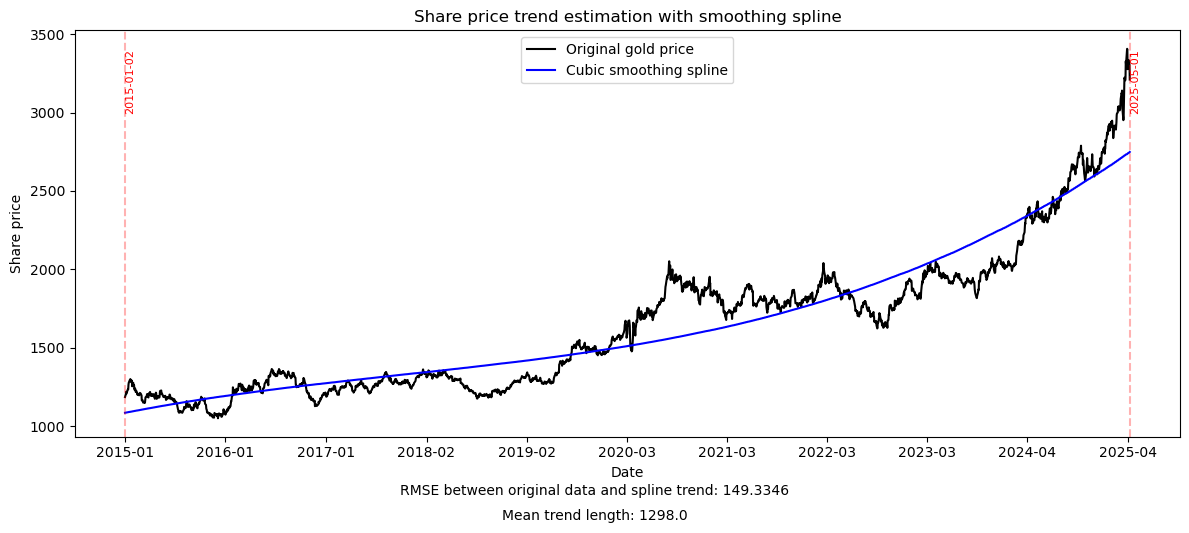

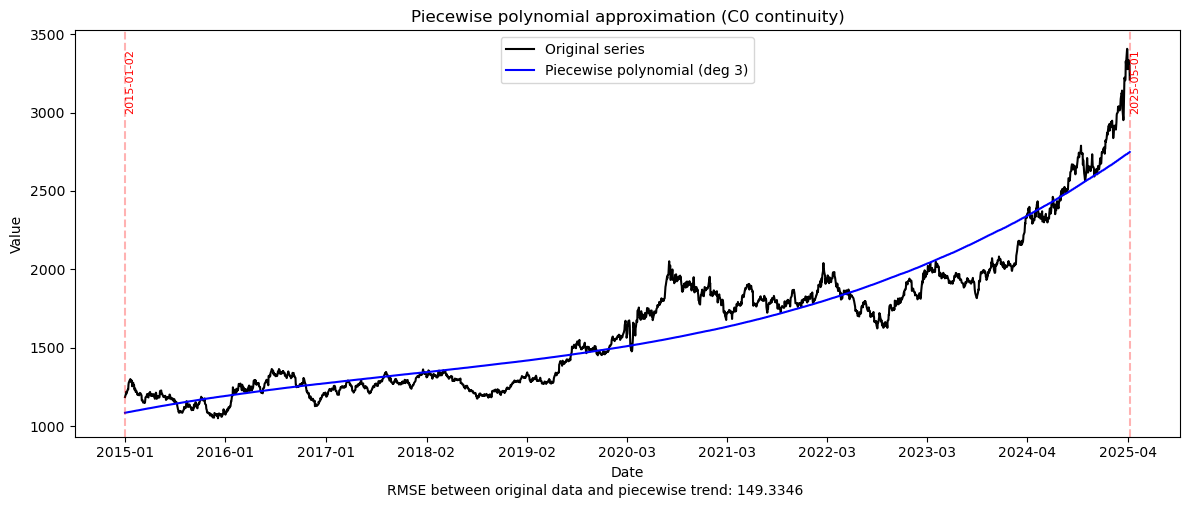

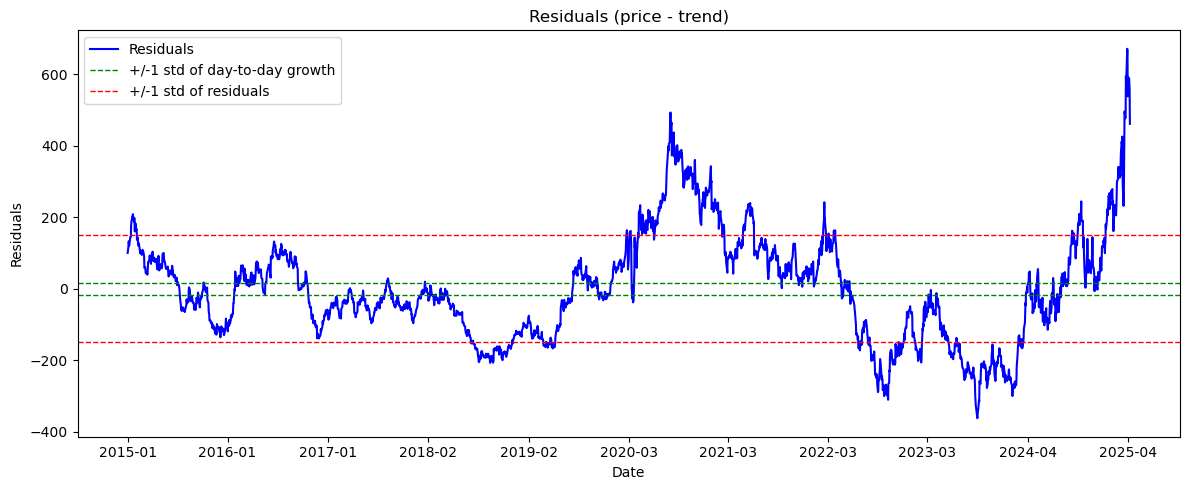

<Figure size 1500x400 with 0 Axes>

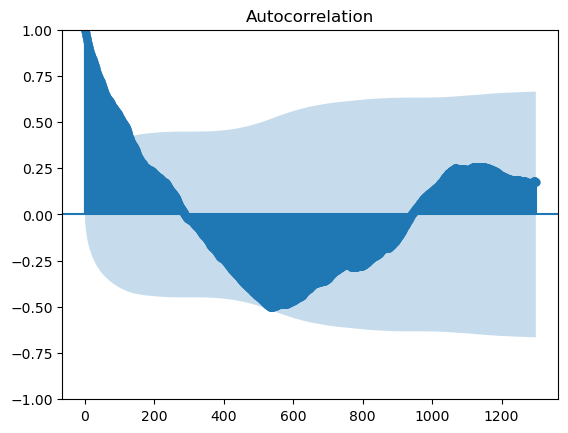

<Figure size 1500x400 with 0 Axes>

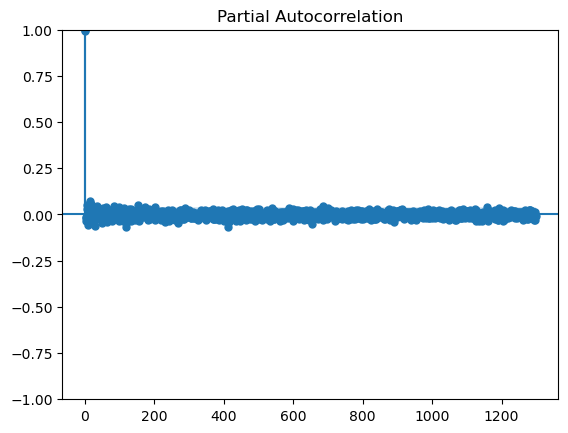

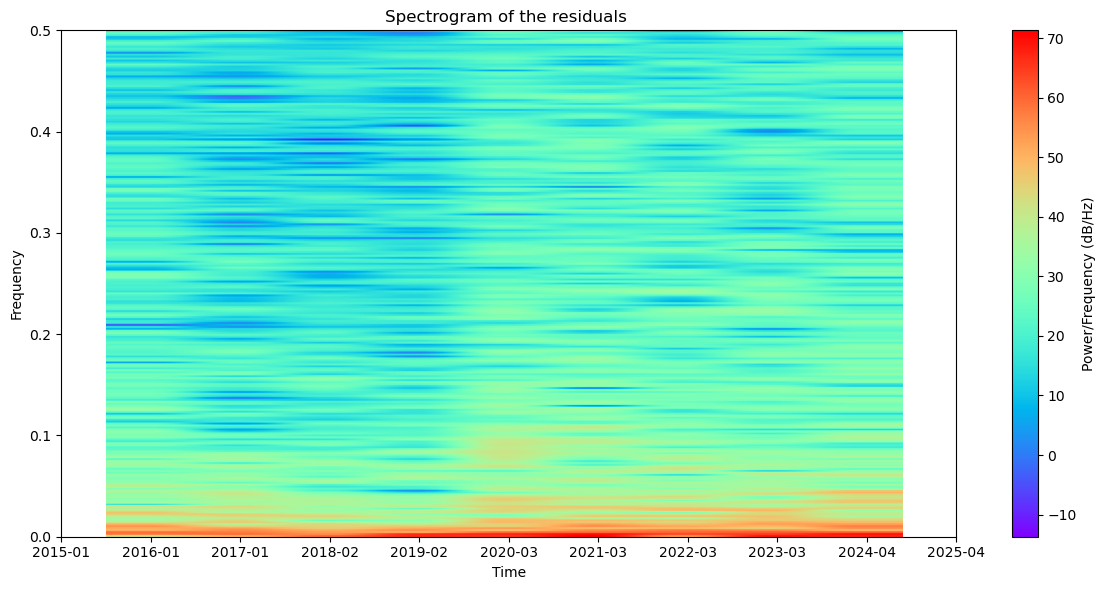

Breakpoints detected by RBF (on residuals): [numpy.datetime64('2015-07-01T00:00:00.000000000'), numpy.datetime64('2015-10-30T00:00:00.000000000'), numpy.datetime64('2016-02-11T00:00:00.000000000'), numpy.datetime64('2016-11-14T00:00:00.000000000'), numpy.datetime64('2018-06-20T00:00:00.000000000'), numpy.datetime64('2019-06-19T00:00:00.000000000'), numpy.datetime64('2019-12-23T00:00:00.000000000'), numpy.datetime64('2020-04-03T00:00:00.000000000'), numpy.datetime64('2020-07-22T00:00:00.000000000'), numpy.datetime64('2020-10-29T00:00:00.000000000'), numpy.datetime64('2021-02-10T00:00:00.000000000'), numpy.datetime64('2021-08-03T00:00:00.000000000'), numpy.datetime64('2022-05-11T00:00:00.000000000'), numpy.datetime64('2022-08-22T00:00:00.000000000'), numpy.datetime64('2022-12-29T00:00:00.000000000'), numpy.datetime64('2023-06-15T00:00:00.000000000'), numpy.datetime64('2024-03-26T00:00:00.000000000'), numpy.datetime64('2024-09-10T00:00:00.000000000'), numpy.datetime64('2025-01-27T00:00:00

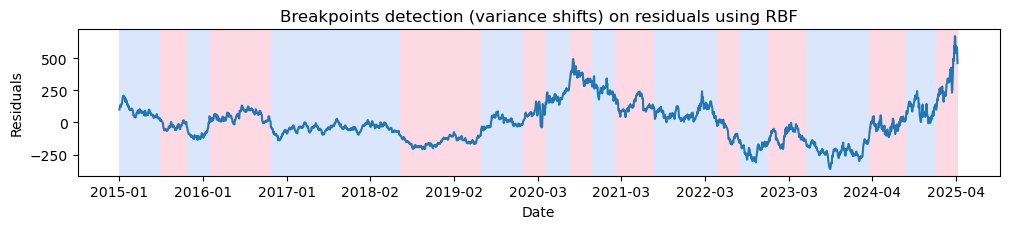

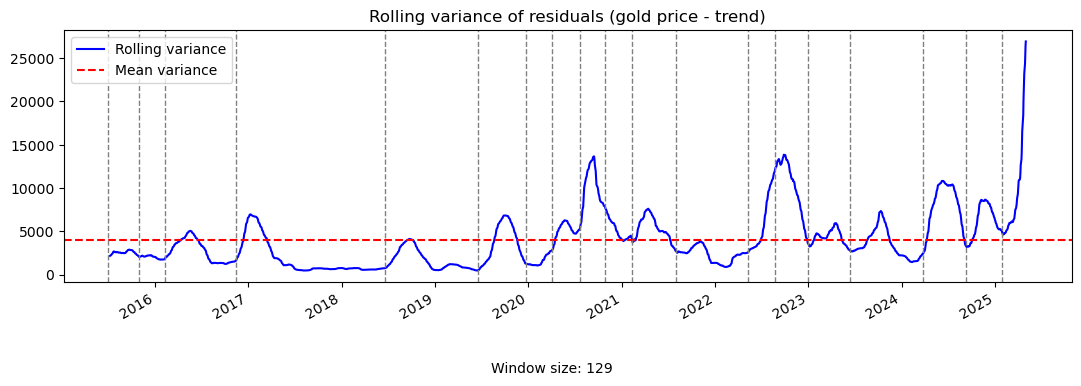


 === Fitting AR/MA/ARMA/ARIMA models... === 
MA(0,0,1) fitted, AIC: 30159.7195


/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


MA(0,0,2) fitted, AIC: 27971.8169
MA(0,0,3) fitted, AIC: 26463.1631
MA(0,0,4) fitted, AIC: 25494.0996
MA(0,0,5) fitted, AIC: 24803.8742
ARIMA(0,1,0) fitted, AIC: 22065.5548
ARIMA(0,1,1) fitted, AIC: 22066.3828
ARIMA(0,1,2) fitted, AIC: 22068.3812
ARIMA(0,1,3) fitted, AIC: 22070.1893
ARIMA(0,1,4) fitted, AIC: 22067.3721
ARIMA(0,1,5) fitted, AIC: 22069.2782
ARIMA(0,2,0) fitted, AIC: 23893.8594
ARIMA(0,2,1) fitted, AIC: 22067.7520
ARIMA(0,2,2) fitted, AIC: 22068.6487
ARIMA(0,2,3) fitted, AIC: 22070.6009
ARIMA(0,2,4) fitted, AIC: 22072.3941
ARIMA(0,2,5) fitted, AIC: 22070.0095
AR(1,0,0) fitted, AIC: 22077.5470
ARMA(1,0,1) fitted, AIC: 22078.7388
ARMA(1,0,2) fitted, AIC: 22080.6946
ARMA(1,0,3) fitted, AIC: 22082.2948
ARMA(1,0,4) fitted, AIC: 22080.2419
ARMA(1,0,5) fitted, AIC: 22082.2271
ARIMA(1,1,0) fitted, AIC: 22066.3818
ARIMA(1,1,1) fitted, AIC: 22068.3826
ARIMA(1,1,2) fitted, AIC: 22070.3812
ARIMA(1,1,3) fitted, AIC: 22070.0852
ARIMA(1,1,4) fitted, AIC: 22067.3011
ARIMA(1,1,5) fitted, 

/home/emilio/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,2,4) fitted, AIC: 22072.2859


...

ARIMA(5,2,3) fitted, AIC: 22074.9307


/home/emilio/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(5,2,4) fitted, AIC: 22075.8524


/home/emilio/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(5,2,5) fitted, AIC: 22068.6179

>>> Best model: ARIMA(2,2,4), AIC: 22062.8806
                                SARIMAX Results                                
Dep. Variable:                       y   No. Observations:                 2596
Model:                  ARIMA(2, 2, 4)   Log Likelihood              -11024.440
Date:              jeu., 24 juil. 2025   AIC                          22062.881
Time:                         22:03:47   BIC                          22103.907
Sample:                              0   HQIC                         22077.747
                                - 2596                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6730      0.010     70.435      0.000       0.654       0.692
ar.L2         -0.9790      0.009   -106

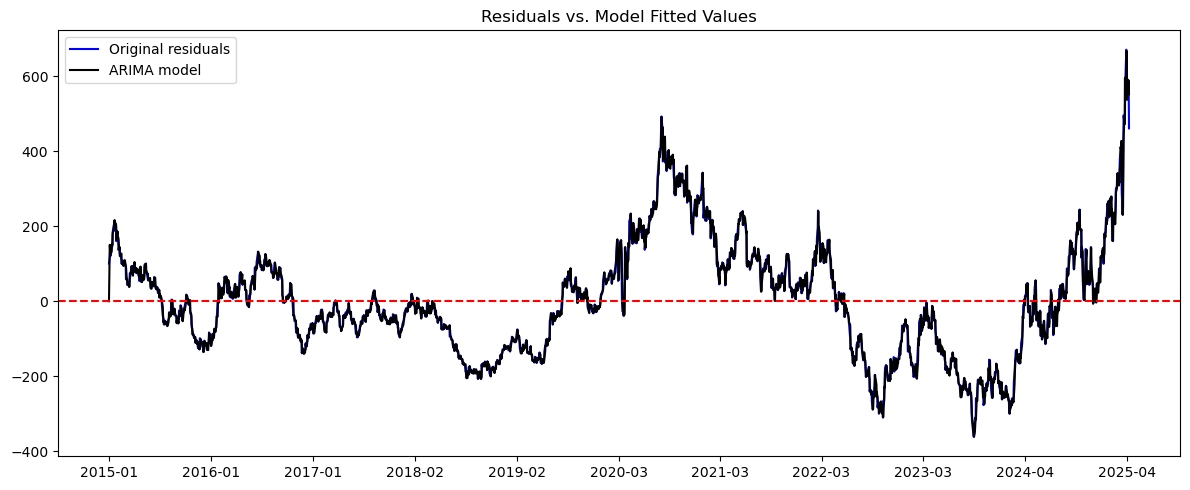

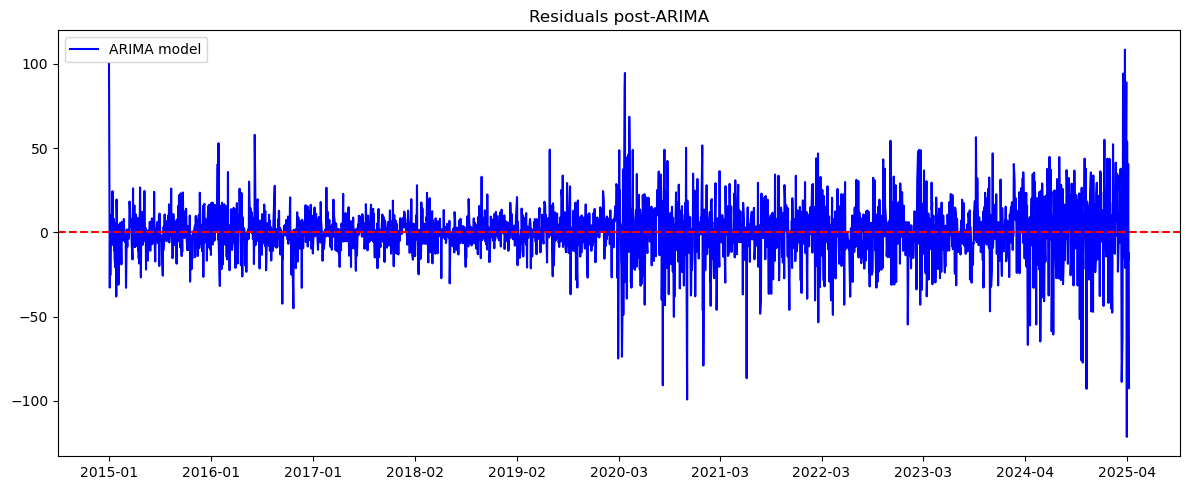

=== ADF Test ===
ADF Statistic: -51.0982, p-value: 0.0000

=== KPSS Test ===
KPSS Statistic: 0.1375, p-value: 0.1000
=== Ljung-Box Test on  Residuals, 60 lags ===
      lb_stat  lb_pvalue
1    0.015941   0.899529
2    0.171237   0.917944
3    0.605618   0.895145
4    2.720596   0.605615
5    2.768422   0.735635
6    4.176849   0.652758
7    5.766828   0.567224
8    7.372468   0.497030
9    7.537364   0.581354
10   7.750787   0.653165
11   7.923466   0.720143
12   9.419740   0.666722
13   9.692991   0.718826
14  10.192429   0.747984
15  12.675103   0.627377
16  18.822836   0.277957
17  19.682521   0.290789
18  19.872915   0.340020
19  19.881830   0.401720
20  20.012829   0.457127
21  20.663839   0.479631
22  20.813834   0.532268
23  20.895077   0.587495
24  21.414920   0.614144
25  22.113608   0.629175
26  25.048897   0.516209
27  25.063493   0.570904
28  34.269500   0.192140
29  34.465420   0.222631
30  34.499500   0.261306
31  35.900968   0.249492
32  38.072126   0.212457
33  38.43837

/tmp/ipykernel_404390/2763397616.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


FIGARCH with normal, p=1, q=1 fitted, AIC: 21292.6957
GARCH with t, p=1, q=1 fitted, AIC: 21034.8540
EGARCH with t, p=1, q=1 fitted, AIC: 21024.2292
FIGARCH with t, p=1, q=1 fitted, AIC: 21034.1314
GARCH with ged, p=1, q=1 fitted, AIC: 21040.8104
EGARCH with ged, p=1, q=1 fitted, AIC: 21032.5635
FIGARCH with ged, p=1, q=1 fitted, AIC: 21041.1292
GARCH with skewt, p=1, q=1 fitted, AIC: 21032.6495
EGARCH with skewt, p=1, q=1 fitted, AIC: 21021.7758
FIGARCH with skewt, p=1, q=1 fitted, AIC: 21032.0951
GARCH with normal, p=1, q=2 fitted, AIC: 21285.7862
EGARCH with normal, p=1, q=2 fitted, AIC: 21275.5770
Error with FIGARCH and normal, p=1, q=2: p and q must be either 0 or 1.
GARCH with t, p=1, q=2 fitted, AIC: 21036.8540
EGARCH with t, p=1, q=2 fitted, AIC: 21026.2292
Error with FIGARCH and t, p=1, q=2: p and q must be either 0 or 1.
GARCH with ged, p=1, q=2 fitted, AIC: 21042.8104
EGARCH with ged, p=1, q=2 fitted, AIC: 21034.5635
Error with FIGARCH and ged, p=1, q=2: p and q must be eith

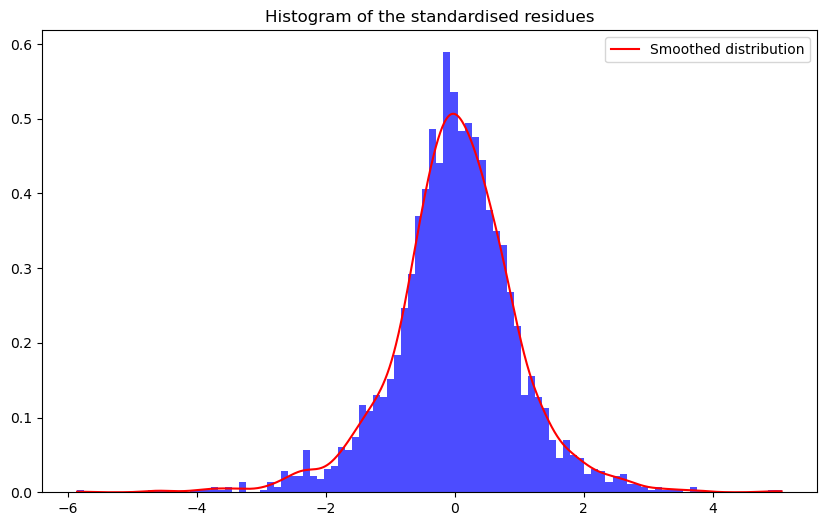

=== ADF Test ===
ADF Statistic: -28.1348, p-value: 0.0000

=== KPSS Test ===
KPSS Statistic: 0.0632, p-value: 0.1000
=== Ljung-Box Test on  Residuals, 60 lags ===
      lb_stat  lb_pvalue
1    0.394528   0.529929
2    0.453279   0.797208
3    4.835842   0.184220
4    4.952124   0.292245
5    5.289237   0.381610
6    5.483362   0.483470
7    6.564614   0.475573
8    6.648204   0.575020
9    6.840713   0.653699
10   7.498469   0.677696
11   7.623706   0.746562
12   8.000632   0.785081
13   8.125071   0.835358
14   8.126754   0.882618
15   8.216643   0.914804
16  12.938682   0.677236
17  13.643147   0.692181
18  13.661362   0.750885
19  14.047459   0.780918
20  15.330195   0.757212
21  15.494825   0.797330
22  15.579328   0.836201
23  16.287097   0.842706
24  16.850982   0.854948
25  17.050205   0.879965
26  18.074130   0.873060
27  18.084601   0.900913
28  23.618648   0.701495
29  23.620012   0.747437
30  24.236974   0.761199
31  24.401758   0.793814
32  26.049287   0.761422
33  26.12563

/tmp/ipykernel_404390/2763397616.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


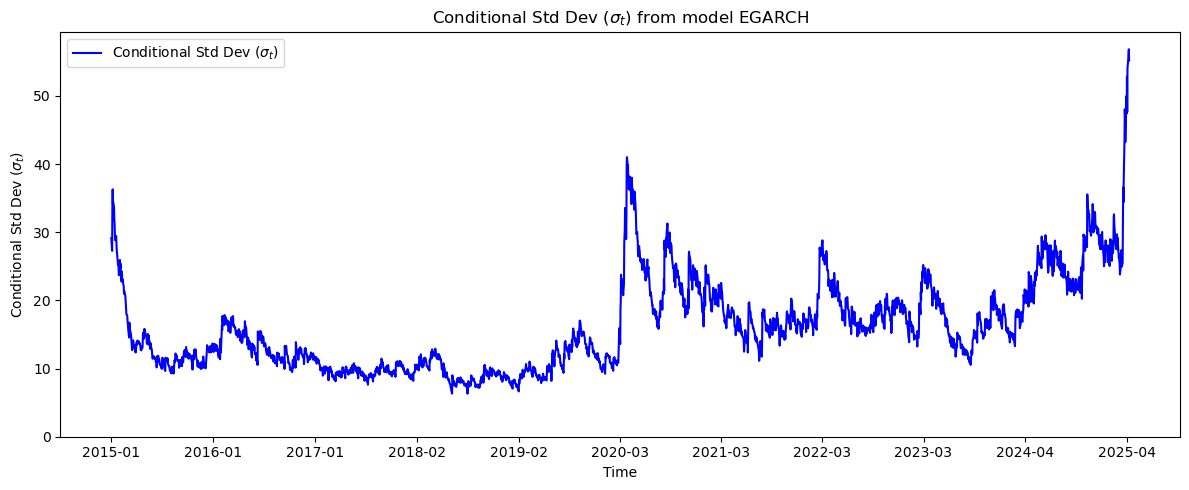

Breakpoints detected by RBF (on residuals): []


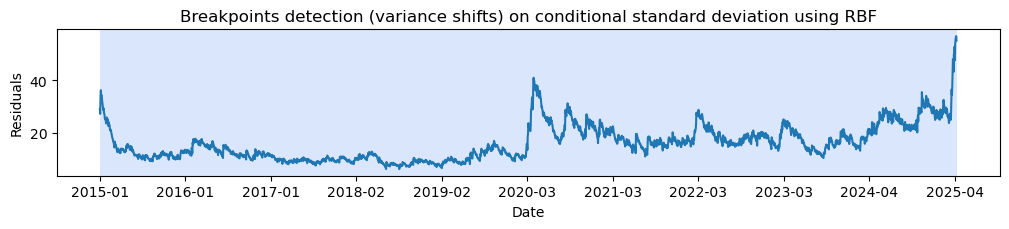

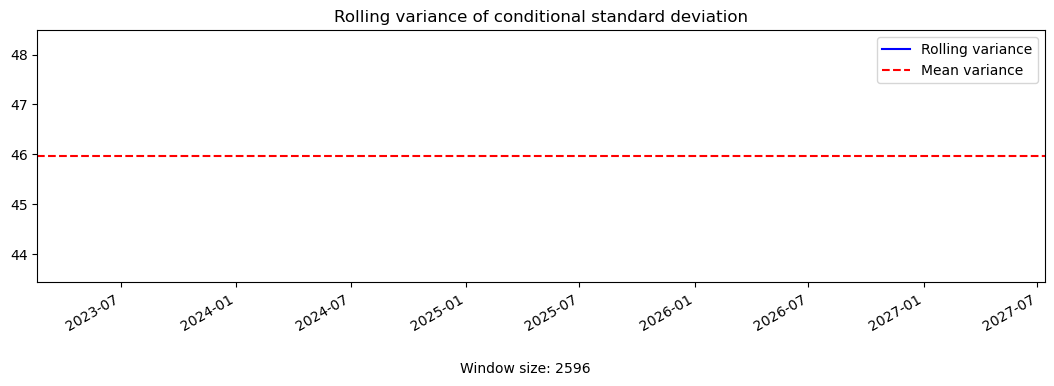

/tmp/ipykernel_404390/2056378528.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = 'green' if mask[i]==True else 'red'


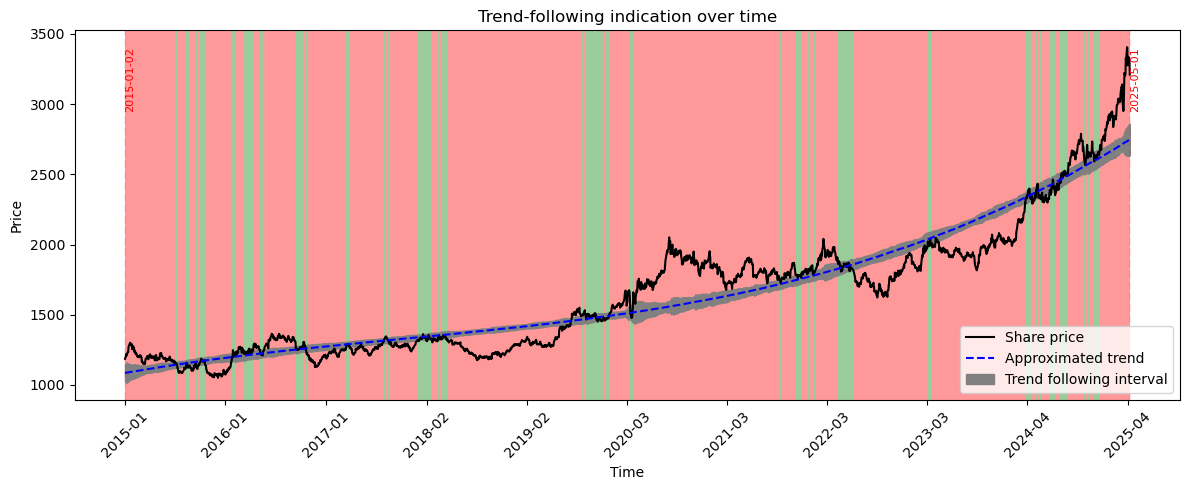

True True


In [ ]:
conditional_vol, breakpoints_rbf, break_dates_rbf, is_following, std_resid_garch, smoothing_param, best_type, best_model, best_garch_model, residuals = farima_garch(gold_2015_2025,  end_date = '2025-05-01', smoothing_param=100000000000 )
print(is_white_noise(std_resid_garch)[0],
is_white_noise(std_resid_garch**2)[0])


### predict

Chosen penalty (smoothing factor): 10000000000.00


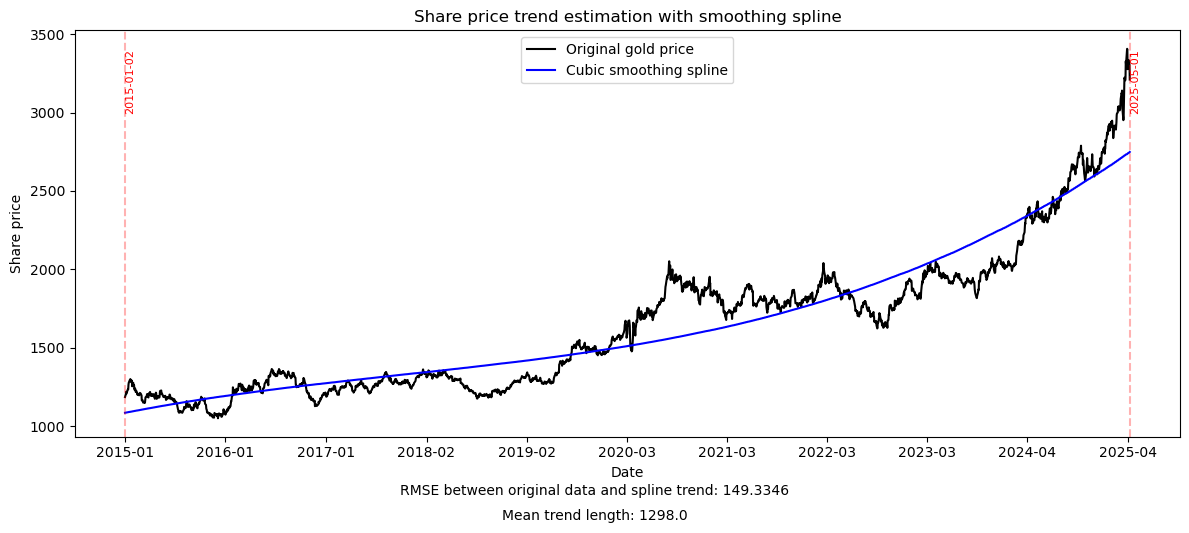

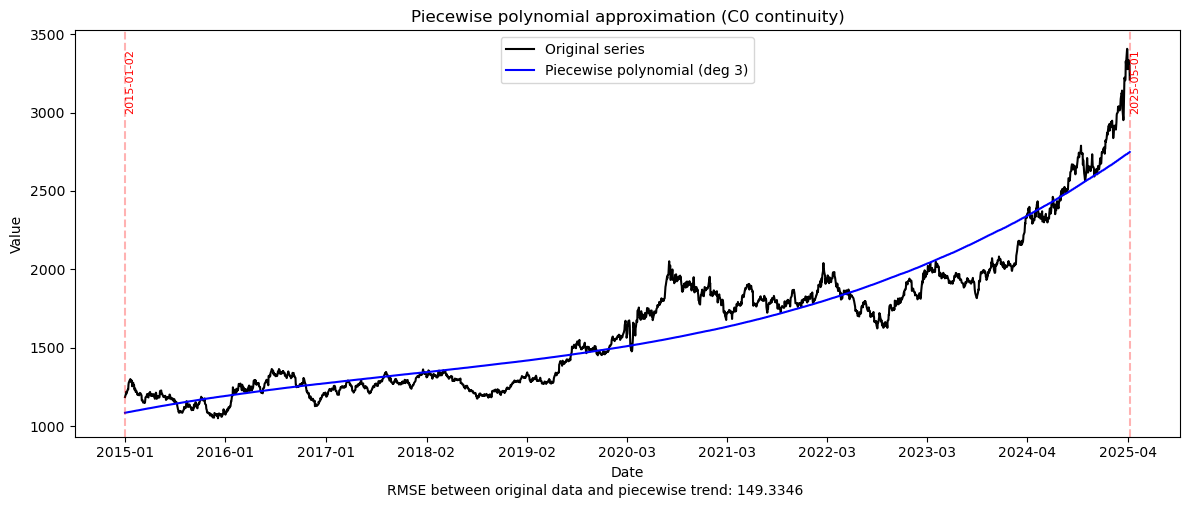

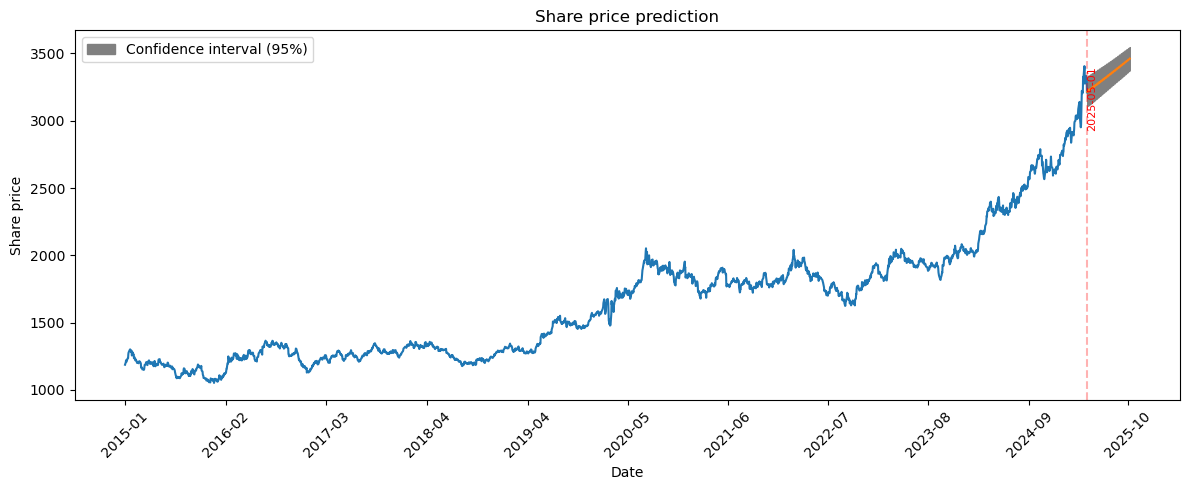

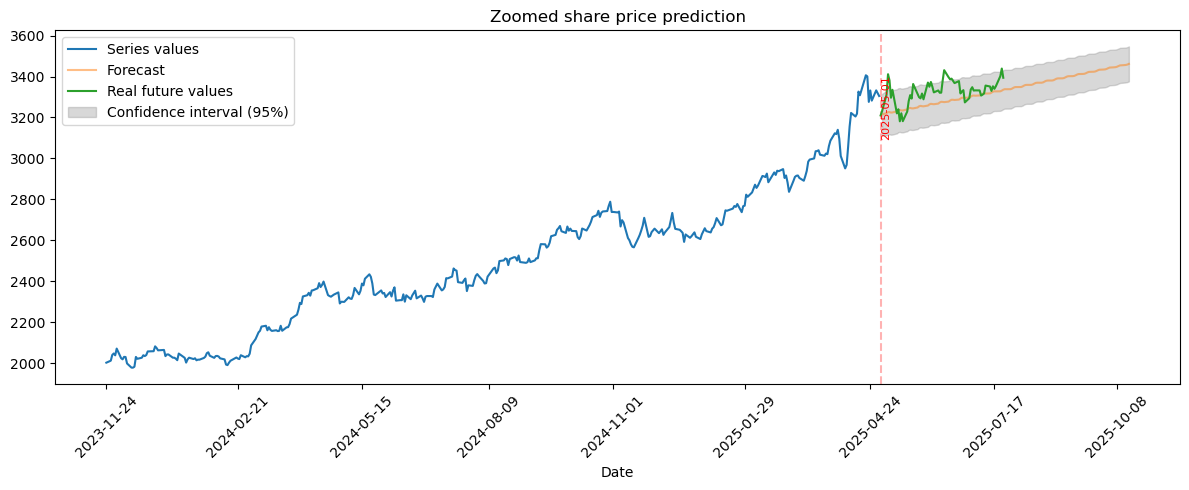

In [ ]:
last_coeffs, x0, y_pred, arima_predict, garch_predict,cond_variance_predict, arima_residues_simulation,asset_predict = prediction_farima_garch(gold_2015_2025, best_model, best_garch_model, end_date='2025-05-01',  n_predict=120,  best_type = best_type, smoothing_param=10000000000)

## comparison

In [ ]:
arima_model = fit_arima_models(gold_2015_2025[:'2025-05-01'], max_p = 5, max_q = 5)
prediction = arima_model.forecast(150)
plt.plot(np.arange(0,150),np.array(prediction))
plt.plot(np.arange(0, 58),gold_2015_2025['2025-05-01':].values.ravel())
plt.ylim(bottom=3200, top=3500)


 === Fitting AR/MA/ARMA/ARIMA models... === 


/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA pa

MA(0,0,1) fitted, AIC: 35699.4269


/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA pa

MA(0,0,2) fitted, AIC: 32827.6761


...

/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

ARIMA(5,2,3) fitted, AIC: 22079.4188


/home/emilio/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

ARIMA(5,2,4) fitted, AIC: 22081.7581
ARIMA(5,2,5) fitted, AIC: 22083.3830

>>> Best model: ARIMA(2,2,4), AIC: 22067.4129
                                SARIMAX Results                                
Dep. Variable:                       y   No. Observations:                 2596
Model:                  ARIMA(2, 2, 4)   Log Likelihood              -11026.706
Date:              jeu., 24 juil. 2025   AIC                          22067.413
Time:                         22:17:03   BIC                          22108.440
Sample:                              0   HQIC                         22082.280
                                - 2596                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6702      0.010     67.626      0.000       0.651       0.690
ar

/home/emilio/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/emilio/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
